In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=42)

N_MARKETS = 20
N_TEST = 5
START = "2025-01-01"
END = "2025-12-31"
LAUNCH = "2025-10-01"
TRUE_LIFT = 0.15

In [2]:
markets = pd.DataFrame({
    "market": [f"market_{i:02d}" for i in range(N_MARKETS)],
    "baseline": rng.integers(50, 500, size=N_MARKETS),
})

test_markets = rng.choice(markets["market"], size=N_TEST, replace=False)
markets["group"] = np.where(markets["market"].isin(test_markets), "test", "control")

In [3]:
dates = pd.DataFrame({"date": pd.date_range(START, END, freq="D")})
df = markets.merge(dates, how="cross")

In [4]:
df.shape

(7300, 4)

In [5]:
df.head()

,market,baseline,group,date
0,market_00,90,control,2025-01-01
1,market_00,90,control,2025-01-02
2,market_00,90,control,2025-01-03
3,market_00,90,control,2025-01-04
4,market_00,90,control,2025-01-05


In [6]:
df.groupby("group")["market"].nunique()

group
control    15
test        5
Name: market, dtype: int64

In [7]:
markets.groupby("group")["baseline"].agg(["mean", "max"])

,mean,max
group,,
control,323.066667,489
test,197.000000,403


In [8]:
df["day_of_week"] = df["date"].dt.dayofweek
df["days_since_start"] = (df["date"] - df["date"].min()).dt.days

weekly = np.where(df["day_of_week"] >= 5, 0.85, 1.0)
trend = 1 + 0.0005 * df["days_since_start"]
noise = rng.normal(loc=1.0, scale=0.08, size=len(df))

df["counterfactual"] = df["baseline"] * weekly * trend * noise

In [9]:
df["post"] = df["date"] >= LAUNCH
df["treated"] = (df["group"] == "test") & df["post"]

df["registrations"] = np.where(
    df["treated"],
    df["counterfactual"] * (1 + TRUE_LIFT),
    df["counterfactual"],
).round().astype(int)

In [10]:
df.groupby(["group", "post"])["registrations"].mean()

group    post 
control  False    329.835653
         True     357.824638
test     False    201.424908
         True     253.132609
Name: registrations, dtype: float64

In [11]:
means = df.groupby(["group", "post"])["registrations"].mean().unstack()
means["pct_change"] = means[True] / means[False] - 1

lift = (1 + means.loc["test", "pct_change"]) / (1 + means.loc["control", "pct_change"]) - 1
print(f"Estimated lift: {lift:.1%}  |  True lift: {TRUE_LIFT:.0%}")

Estimated lift: 15.8%  |  True lift: 15%


Matplotlib is building the font cache; this may take a moment.


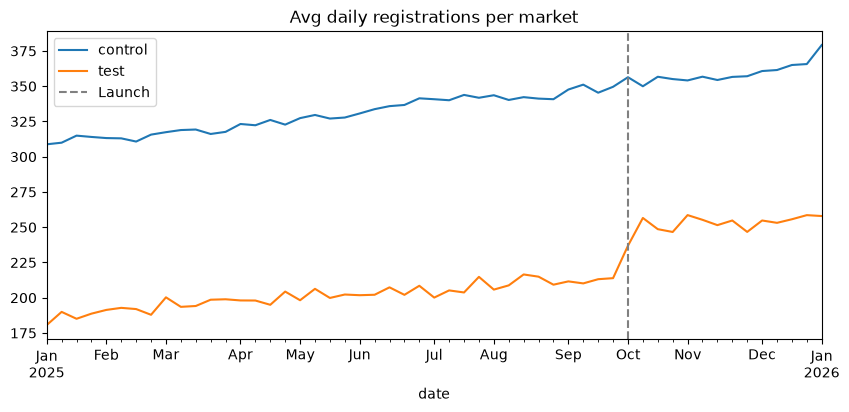

In [12]:
import matplotlib.pyplot as plt

weekly_avg = (
    df.groupby([pd.Grouper(key="date", freq="W"), "group"])["registrations"]
    .mean()
    .unstack()
)

ax = weekly_avg.plot(figsize=(10, 4), title="Avg daily registrations per market")
ax.axvline(pd.Timestamp(LAUNCH), color="gray", linestyle="--", label="Launch")
ax.legend()
plt.show()